In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import torchaudio.transforms as T
import math   
from src.dataset import NSynth
import torch
from src.diffusion import *

mnist_datasets_path = r'C:\Users\Articuno\Desktop\TFG-info\data\mnist'
diff_mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff_mnist.pth'

diff_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\diff.pth'
temp_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\temp.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# STFT transform
sample_rate = 16000
n_fft = 1500
hop_length = 250
win_length = n_fft
stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=2.0, onesided=False, center=False
).to(device)

In [3]:
def train_minst(input_size, epochs, batch_size=16, lr=1e-3, path=mnist_datasets_path):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    best_loss = 1
    
    # train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())
    train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        for x, _ in train_loader:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), diff_mnist_model_path)
            print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    return model, scheduler

In [4]:
def train(
    model, 
    epochs=1000, 
    batch_size=16, 
    lr=1e-3, 
    model_path=None, 
    dataset=NSynth('training'), 
    verb=False
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
    
    for epoch in range(epochs):
        for x, _ in train_loader:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        losses.append(loss.item())
            
        if epoch % 10 == 0:
            if verb:
                print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            if model_path is not None:
                torch.save(model.state_dict(), model_path)
                if verb:
                    print(f"Model temporally saved at epoch {epoch} with loss {best_loss}")
            else:
                torch.save(model.state_dict(), temp_path)
                if verb:
                    print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    if model_path is not None:
        model.load_state_dict(torch.load(model_path))
    else:
        model.load_state_dict(torch.load(temp_path))
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

In [5]:
   
def train_old(input_size, epochs=1000, batch_size=16, lr=1e-3, path=diff_model_path):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    best_loss = 1
    
    # train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(NSynth('training'), batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler()
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        for wave, _, _, _ in train_loader:
            wave = wave.to(device)

            # en principio autocast hacia que sea mas eficiente en memoria pero se ve que no lo suficiente
            with torch.cuda.amp.autocast():
                x = stft_transform(wave)
                batch_size = x.size(0)

                t = torch.randint(0, epochs, (batch_size,), device=device)

                z, e = diffuser(x, t)
                e_pred = model(z, t)

                loss = mse_loss(e_pred, e)

            optimizer.zero_grad()

            # backward con escala
            scaler.scale(loss).backward()

            # step escalado
            scaler.step(optimizer)

            # actualiza escala interna
            scaler.update()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), diff_model_path)
            print(f"Model saved at epoch {epoch} with loss {best_loss}")
    return model, scheduler


In [6]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)

    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()

    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()

    return x


In [ ]:
sin = 64
sout = 128
norm_groups = 8
num_epochs = 10

layers = [
    DummyLayer(sin, 128, norm_groups).to(device),
    DummyLayer(128, sout, norm_groups).to(device),
]

x = torch.randn(1, 64, 16, 16).to(device)  # Example input
t_emb = torch.randn(1, 128).to(device)     # Example embedding

# for i, layer in enumerate(layers):
#     print(f"Layer {i}: x.shape = {x.shape}")
#     try:
#         x, r = layer(x, t_emb)
#     except Exception as e:
#         print(f"Error in layer {i}: {e}")
#         break

# TODO fix lo de las layers que es un lio

embedder = Embeder(num_epochs=num_epochs, embed_dim=128, device=device)
scheduler = Scheduler(num_epochs=num_epochs, device=device).to(device)

model = DiffusionModel(
    channels=[sin, sout], # entrada y salida de las layers
    norm_groups=norm_groups,
    layers=layers,
    embedder=embedder,
    input_channels=1,
    output_channels=1        
).to(device)

losses = []

In [8]:
mnist_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())
synt_ds = NSynth('training')

In [9]:
%%time
model, scheduler, losses = train(
    model, 
    epochs=1000, 
    batch_size=16, 
    lr=1e-3, 
    model_path=diff_mnist_model_path, 
    dataset=mnist_ds,
    verb=True,
)
plt.plot(losses)

RuntimeError: Expected weight to be a vector of size equal to the number of channels in input, but got weight of shape [256] and input of shape [16, 64, 28, 28]

Losses:


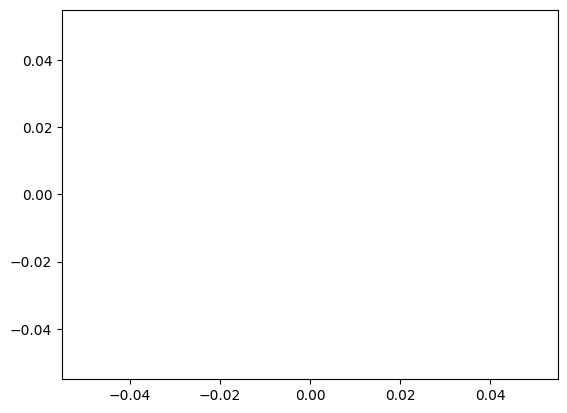

In [10]:
print('Losses:')
plt.plot(losses)

In [11]:
_ = sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28))

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
